# Image Processing Assessment

Complete the tasks in bold below! Feel free to treat this as a code along by skipping this assessment lecture and moving straight to the solutions lecture!

**Some Useful Code is already here for you in the cells below:**

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
def display_img(img,cmap=None):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap)

---
**TASK: Open and display the giaraffes.jpg image that is located in the DATA folder.**

In [ ]:
GIRAFFES_PATH ='giraffes.jpg'
GIRAFFES_BGR  = cv2.imread(GIRAFFES_PATH)
GIRAFFES_RGB  = cv2.cvtColor(cv2.imread(GIRAFFES_PATH), cv2.COLOR_BGR2RGB)
GIRAFFES_GRAY = cv2.imread(GIRAFFES_PATH, 0)

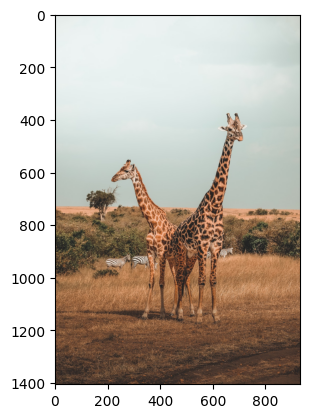

In [4]:
plt.imshow(GIRAFFES_RGB)

---
**TASK:Apply a binary threshold onto the image.**

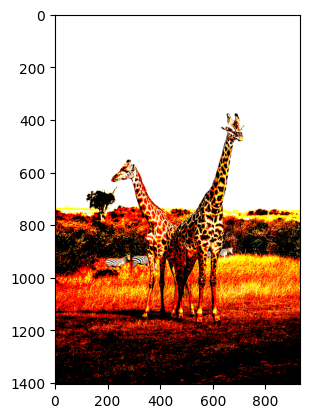

In [5]:
# RGB BIN THRESH
treshold = 127
maxvalue = 255

ret, giraffes_rgb_binary_thresh = cv2.threshold(GIRAFFES_RGB,
                                            treshold,
                                            maxvalue,
                                            cv2.THRESH_BINARY)

plt.imshow(giraffes_rgb_binary_thresh,
           cmap = 'gray')                                            

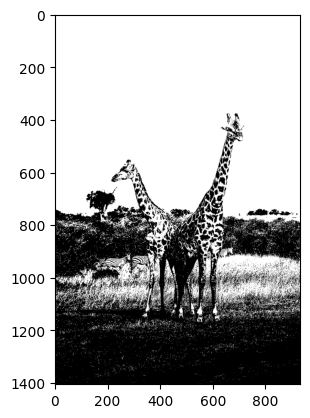

In [6]:
# GRAY BIN THRESH
ret, girrages_gray_binary_thresh = cv2.threshold(GIRAFFES_GRAY.copy(),
                                                treshold,
                                                maxvalue,
                                                cv2.THRESH_BINARY)

plt.imshow(girrages_gray_binary_thresh,
           cmap = 'gray')

#### Explain the role of the threshold for each one that you have applied to.

##### Answer:
- binary_dst = 
    - MAX if: src > threshold
    - 0 else

---
**TASK: Open the giraffes.jpg file from the DATA folder and convert its colorspace to  HSV and display the image.**

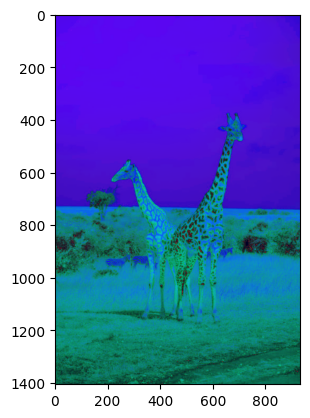

In [7]:
# CONVERT TO HSV
GIRAFFES_HSV = cv2.cvtColor(GIRAFFES_BGR, cv2.COLOR_BGR2HSV)
plt.imshow(GIRAFFES_HSV)

#### What if you convert it to HSL? Explain the difference between them

##### Answer:

| HSL | Definition | HSV | Definition | Range      |
| --- | ---------- | --- | ---------- | ---------- |
|  H  | Hue        |  H  | Hue        | 0-255: Int |
|  S  | Saturation |  S  | Saturation | 0-100: %   |
|  L  | Lightness  |  V  | Value      | 0-100: %   |

Both these colourspaces have their first two components named the same (Hue and Saturation), but they differ in numerival representativeness:

#### Key Differences:

**1. Third Component:**
- **HSL (Lightness)**: Lightness = 0% means black, 50% means the pure color, and 100% means white.
- **HSV (Value)**: Value = 0% means black, while Value = 100% means the color is at its maximum brightness.

**1. Saturation Behavior:**
- **HSL**: Relative to gray
- **HSV**: Relative to white

**1. Visual Perception:**
- **HSL**: The double-cone model where L=50% represents pure hues
- **HSV**: The cylinder model where V controls the "cap" height

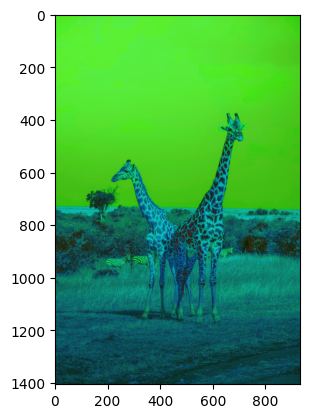

In [8]:
# CONVERT TO HLS
GIRAFFES_HLS = cv2.cvtColor(GIRAFFES_BGR, cv2.COLOR_BGR2HLS)
plt.imshow(GIRAFFES_HLS)

---
**TASK: Create a low pass filter with a 4 by 4 Kernel filled with values of 1/10 (0.01) and then use 2-D Convolution to blur the giraffe image (displayed in normal RGB)**

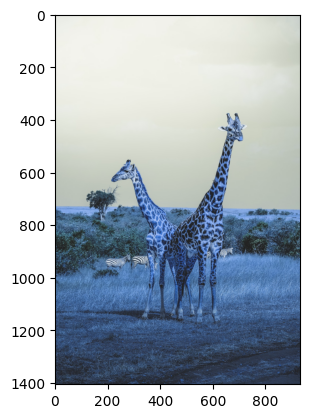

In [9]:
GIRAFFES_FLOAT32 = cv2.imread(GIRAFFES_PATH).astype(np.float32) / 255.0
plt.imshow(GIRAFFES_FLOAT32)

In [10]:
def plot_original_vs_filtered(filtered):
    fig = plt.figure(figsize=(12,10))
    
    ax1 = fig.add_subplot(121)
    ax1.set_title('Original Image')
    ax1.imshow(GIRAFFES_FLOAT32)
    
    ax2 = fig.add_subplot(122)
    ax2.set_title('Filtered Image')
    ax2.imshow(filtered)

In [11]:
kernel_shape = (4, 4)
kernel_1_over_10 = np.ones(shape = kernel_shape,
                           dtype = np.float32) / 10

kernel_1_over_100 = np.ones(shape = kernel_shape,
                            dtype = np.float32) / 100

In [12]:
kernel_1_over_10

array([[0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1]], dtype=float32)

In [13]:
kernel_1_over_100

array([[0.01, 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, 0.01],
       [0.01, 0.01, 0.01, 0.01]], dtype=float32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14431372..1.5698041].


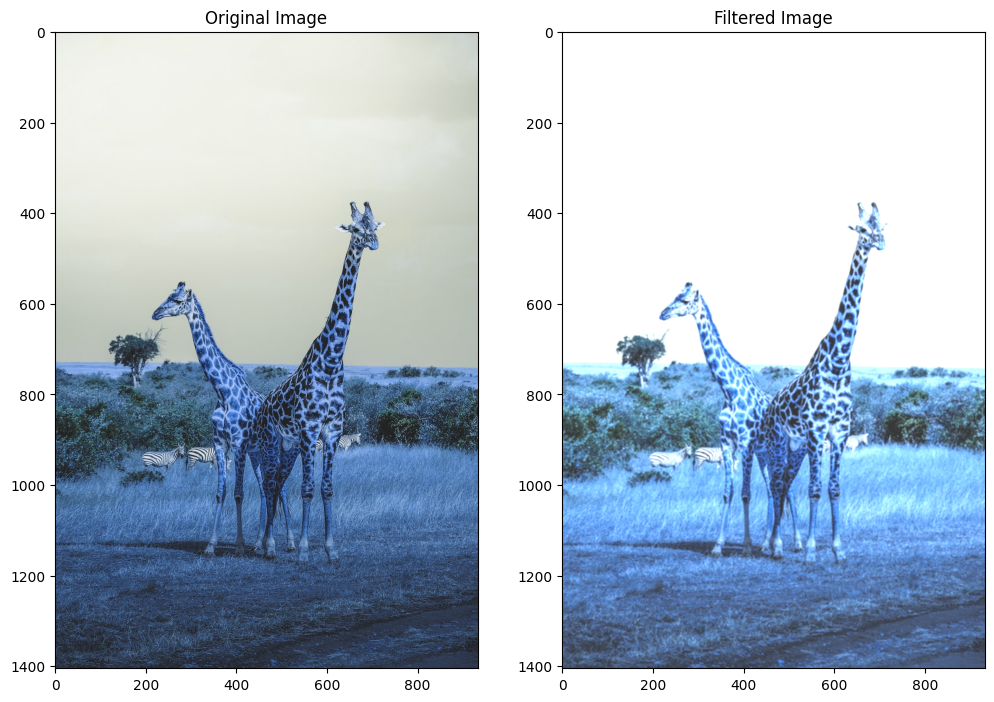

In [14]:
destination_1_over_10 = cv2.filter2D(GIRAFFES_FLOAT32.copy(),
                                     -1,
                                     kernel_1_over_10)

plot_original_vs_filtered(destination_1_over_10)

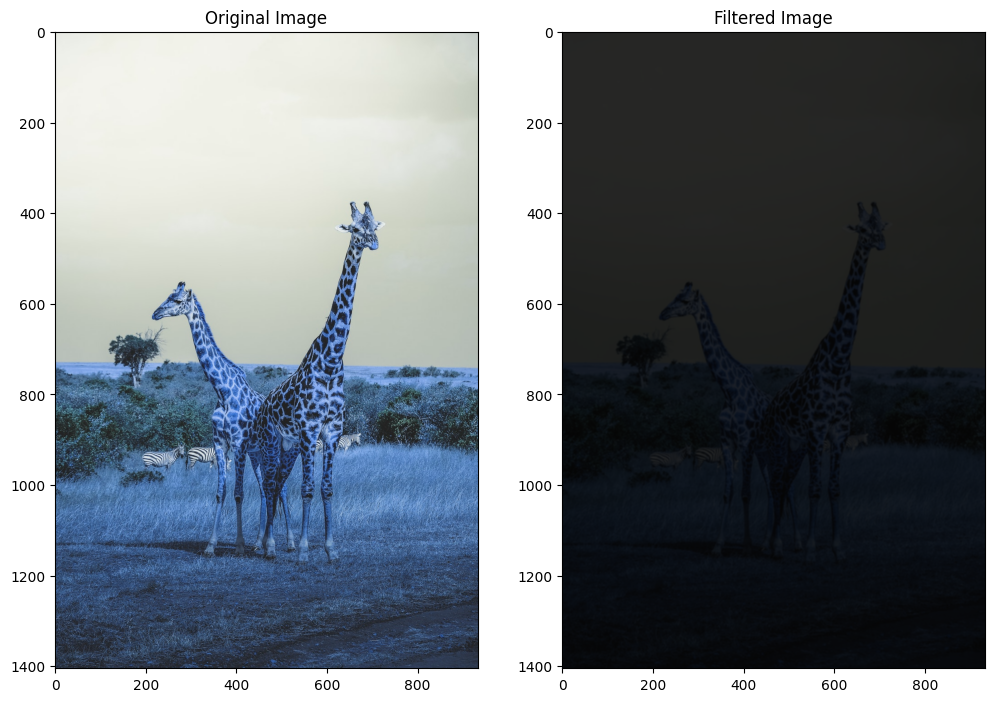

In [15]:
destination_1_over_100 = cv2.filter2D(GIRAFFES_FLOAT32.copy(),
                                      -1,
                                      kernel_1_over_100)

plot_original_vs_filtered(destination_1_over_100)

#### You must explain step by step what you are doing by getting it done.
##### Answer:
1. Create a 4x4 Kernel filled with One's divided by 10 (0.1), then by 100 (0.01).
1. Apply a 2D filter on the Giraffes image using `cv2.filter2D()` with each kernel.
1. The function performs **convolutions** by moving the kernel over each pixel in the image.
1. For each position, the image values are multiplied by the kernel, then the products are summed up.
1. The new value is the weighted average of the neighborhoods within the kernel/window.

#### As you apply the filter, explain its role and why we should take it 
##### Answer:

**Low-Pass Filtering**: Acts as a **smoothing/blurring filter** that removes details such as random digital cameras noise by averiging the pixel values. Bigger kernels tend to have are stronger blurring effects by making details less visible/distinguishable.

**1/10 vs 1/100:**
- **1/10 kernel**: Stronger averaging - **amplifies** the image
- **1/100 kernel**: Smoother averaging - **darkens** the image
---

### Now, the next two questions are a sort of challenge, so beat it!!

**TASK: Create a Horizontal Sobel Filter (sobelx from our lecture) with a kernel size of 5 to the grayscale version of the giaraffes image and then display the resulting gradient filtered version of the image.**

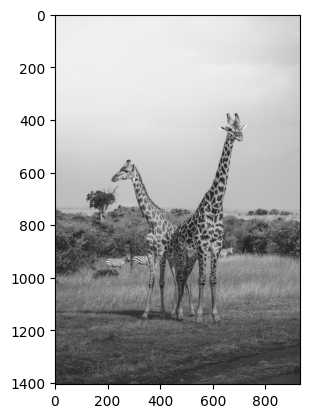

In [16]:
plt.imshow(GIRAFFES_GRAY,
           cmap = 'gray')

In [17]:
sobelx = cv2.Sobel(GIRAFFES_GRAY,
                   cv2.CV_64F,
                   1,
                   0,
                   ksize=5)

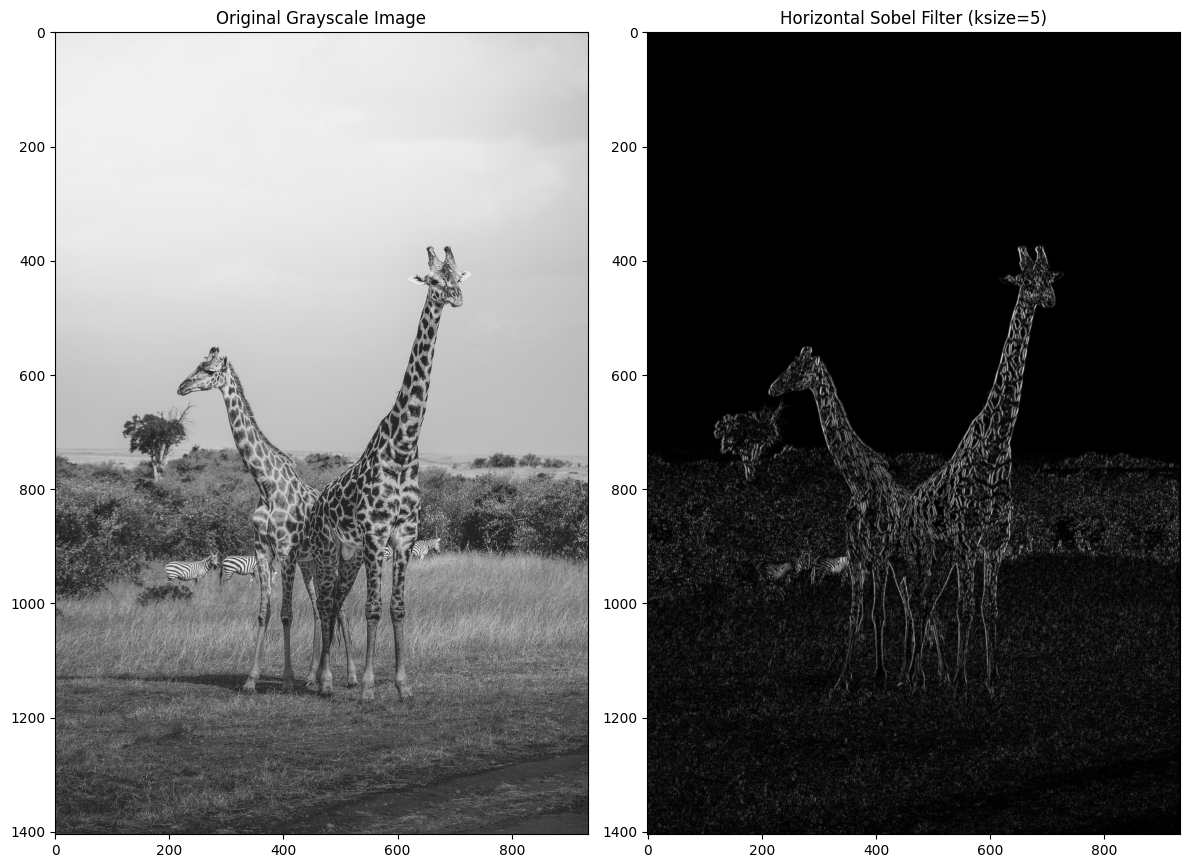

In [18]:
# Original
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.imshow(GIRAFFES_GRAY, cmap='gray')
plt.title('Original Grayscale Image')

# Sobel
plt.subplot(1, 2, 2)
plt.imshow(np.abs(sobelx), cmap='gray')
plt.title('Horizontal Sobel Filter (ksize=5)')
plt.tight_layout()
plt.show()

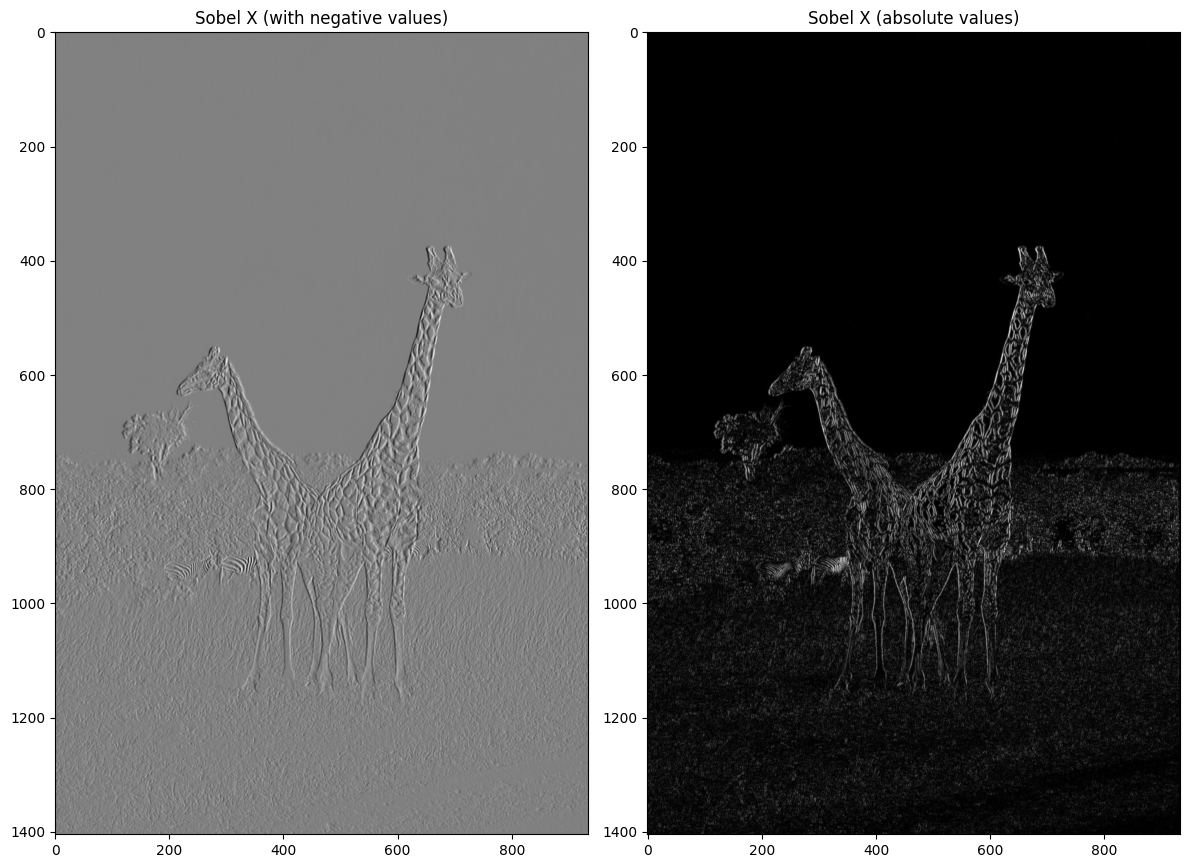

In [19]:
# Sobel including negative values
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.imshow(sobelx, cmap='gray')
plt.title('Sobel X (with negative values)')

# Sobel only absolut values 
plt.subplot(1, 2, 2)
plt.imshow(np.abs(sobelx), cmap='gray')
plt.title('Sobel X (absolute values)')
plt.tight_layout()
plt.show()

---
**TASK: Plot the color histograms for the RED, BLUE, and GREEN channel of the giaraffe image. Pay careful attention to the ordering of the channels.**

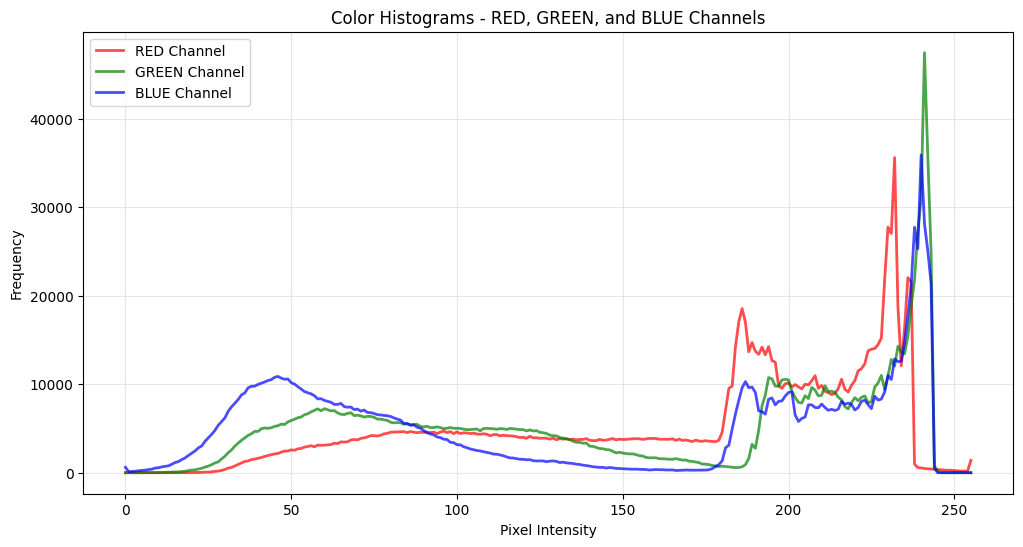

In [20]:
# Plot color histograms for RED, BLUE, and GREEN channels using line plots
# Note: GIRAFFES_RGB is already in RGB format, so channel ordering is:
# Channel 0 = RED, Channel 1 = GREEN, Channel 2 = BLUE

plt.figure(figsize=(12, 6))

# Calculate histograms for each channel
red_hist,   bins = np.histogram(GIRAFFES_RGB[:,:,0].ravel(), bins=256, range=[0,256])
green_hist, _    = np.histogram(GIRAFFES_RGB[:,:,1].ravel(), bins=256, range=[0,256])
blue_hist,  _    = np.histogram(GIRAFFES_RGB[:,:,2].ravel(), bins=256, range=[0,256])

# Create bin centers for plotting
bin_centers = bins[:-1]

# Plot all three channels as line plots in single subplot
plt.plot(bin_centers, red_hist,   color='red',   alpha=0.7, linewidth=2, label='RED Channel')
plt.plot(bin_centers, green_hist, color='green', alpha=0.7, linewidth=2, label='GREEN Channel')
plt.plot(bin_centers, blue_hist,  color='blue',  alpha=0.7, linewidth=2, label='BLUE Channel')

plt.title('Color Histograms - RED, GREEN, and BLUE Channels')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Great job!